### **Importing necessary libraries**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


### **Load the Dataset**

In [5]:
DATASET_PATH = "A_Z Handwritten Data.csv"
print("Loading dataset...")
data = pd.read_csv(DATASET_PATH)

# Extract labels and images from the CSV file
labels = data.iloc[:, 0].values  # First column contains the labels
images = data.iloc[:, 1:].values  # Remaining columns contain the pixel values

# Reshape the image data to 28x28
images = images.reshape(-1, 28, 28) 
print(f"Dataset loaded successfully! Total images: {len(images)}")

Loading dataset...
Dataset loaded successfully! Total images: 372450


### **Identify unique classes and their counts**

In [6]:
unique_classes, class_counts = np.unique(labels, return_counts=True)
print(f"Number of unique classes: {len(unique_classes)}")
print(f"Classes: {unique_classes}")
print(f"Class Counts: {class_counts}")

Number of unique classes: 26
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Class Counts: [13869  8668 23409 10134 11440  1163  5762  7218  1120  8493  5603 11586
 12336 19010 57825 19341  5812 11566 48419 22495 29008  4182 10784  6272
 10859  6076]


### **Visualize Class Distribution**

#### **Create a DataFrame for better visualization**

In [7]:
class_distribution = pd.DataFrame({
    "Class": unique_classes,
    "Count": class_counts
}).sort_values(by="Class")

#### **Plot the distribution**

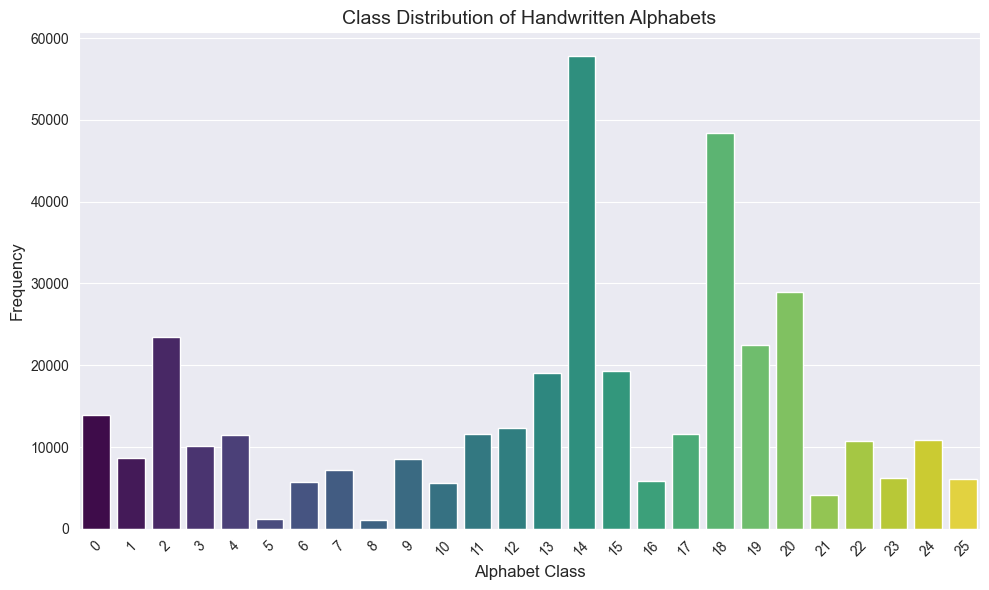

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Class", y="Count", data=class_distribution, hue="Class", dodge=False, palette="viridis", legend=False)
plt.title("Class Distribution of Handwritten Alphabets", fontsize=14)
plt.xlabel("Alphabet Class", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")  # Save the plot as an image
plt.show()

### **Normalize the image data**


In [13]:
images = images / 255.0
print("Image data normalized successfully!")

Image data normalized successfully!


### **Normalize the image data**

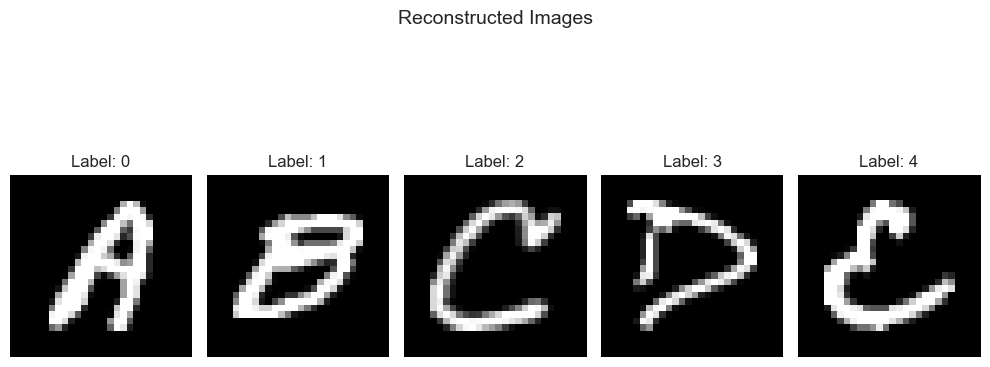

In [14]:
unique_labels = np.unique(labels)
plt.figure(figsize=(10, 5))
for i, label in enumerate(unique_labels[:5]):  # Visualize first 5 unique classes
    idx = np.where(labels == label)[0][0]  # Get the first index of the label
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[idx], cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.suptitle("Reconstructed Images", fontsize=14)
plt.tight_layout()
plt.savefig("reconstructed_images.png")  # Save the plot as an image
plt.show()

### **Split the dataset into training and testing sets**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
print(f"Training Set: {len(X_train)} images")
print(f"Testing Set: {len(X_test)} images")

Training Set: 297960 images
Testing Set: 74490 images
